# MediaPipe 자세 데이터 전처리 파이프라인

## 목적
실제 운동 영상에서 MediaPipe로 추출한 자세 데이터를 전처리하여,
노이즈 제거 및 데이터 품질 개선 효과를 시각화합니다.

## 전처리 단계
1. **이상치 탐지 및 제거** (z-score 기반)
2. **Temporal Smoothing** (Savitzky-Golay 필터)
3. **포즈 정규화** (스케일 및 위치 불변성)

---

## 1. 라이브러리 임포트

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 한글 깨짐 방지 설정 추가 ---
import matplotlib.font_manager as fm

# 윈도우의 경우 'Malgun Gothic'을 설정합니다.
plt.rcParams['font.family'] = 'Malgun Gothic'
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
# 그래프를 더 선명하게 (Retina 디스플레이 효과)
%config InlineBackend.figure_format = 'retina'
# ------------------------------

# 프로젝트 루트를 Python 경로에 추가
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from app.services.pose_similarity import PoseSimilarityAnalyzer
from app.services.pose_preprocessing import PoseDataProcessor

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ 라이브러리 로드 및 한글 폰트 설정 완료")

c:\Users\YUN\anaconda3\envs\healthcare\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
ERROR:prophet.plot:Importing plotly failed. Interactive plots will not work.


✅ 라이브러리 로드 및 한글 폰트 설정 완료


## 2. 실제 영상에서 MediaPipe 데이터 추출

운동 영상에서 MediaPipe를 사용하여 33개 랜드마크(99차원 벡터)를 추출합니다.

In [2]:
# 영상 경로 설정
VIDEO_PATH = r"C:\Users\YUN\Desktop\Web-load-Prediction-main\data\sample_exercise.mp4"  # 영상 파일 경로

# MediaPipe 분석기 초기화 (전처리 비활성화 - 원본 데이터만 추출)
analyzer = PoseSimilarityAnalyzer(enable_preprocessing=False)

print(f"📹 영상 분석 시작: {VIDEO_PATH}")
print(f"⏳ MediaPipe로 자세 데이터 추출 중...\n")

# 원본 데이터 추출
result = analyzer.extract_video_pose_sequence(
    video_path=VIDEO_PATH,
    sample_rate=3,  # 3프레임마다 샘플링
    apply_preprocessing=False  # 원본만 추출
)

raw_sequence = result['raw_sequence']

print(f"✅ 추출 완료!")
print(f"   - 총 프레임 수: {len(raw_sequence)}개")
print(f"   - 데이터 형태: {raw_sequence[0].shape if raw_sequence else 'N/A'}")
print(f"   - 랜드마크 수: 33개 (x, y, z) = 99차원")

INFO:app.services.pose_similarity:Preprocessing pipeline disabled


📹 영상 분석 시작: C:\Users\YUN\Desktop\Web-load-Prediction-main\data\sample_exercise.mp4
⏳ MediaPipe로 자세 데이터 추출 중...



INFO:app.services.pose_similarity:Extracted 89 raw frames from 266 total frames


✅ 추출 완료!
   - 총 프레임 수: 89개
   - 데이터 형태: (99,)
   - 랜드마크 수: 33개 (x, y, z) = 99차원


## 3. 전처리 파이프라인 적용

추출된 원본 데이터에 3단계 전처리를 적용합니다.

In [3]:
# 전처리기 초기화
preprocessor = PoseDataProcessor(confidence_threshold=0.5)

print("🔧 전처리 파이프라인 실행...\n")

# Step 1: 이상치 제거
print("[1/3] 이상치 탐지 및 제거 (z-score 기반)")
cleaned_sequence, cleaning_stats = preprocessor.clean_sequence(raw_sequence)
print(f"   ✓ 제거된 프레임: {cleaning_stats['removed_frames']}개")
print(f"   ✓ 보간된 프레임: {cleaning_stats['interpolated_frames']}개")
print(f"   ✓ 제거율: {cleaning_stats['removal_rate']*100:.2f}%\n")

# Step 2: 스무딩
print("[2/3] Temporal Smoothing (Savitzky-Golay 필터)")
smoothed_sequence = preprocessor.smooth_sequence(
    cleaned_sequence,
    window_length=5,
    polyorder=2
)
print(f"   ✓ 스무딩 완료: {len(smoothed_sequence)}개 프레임\n")

# Step 3: 정규화
print("[3/3] 포즈 정규화 (스케일 및 위치 불변성)")
normalized_sequence = [preprocessor.normalize_pose(pose) for pose in smoothed_sequence]
print(f"   ✓ 정규화 완료\n")

print("✅ 전처리 파이프라인 완료!")

INFO:app.services.pose_preprocessing:Cleaning stats: {'original_frames': 89, 'cleaned_frames': 89, 'removed_frames': 0, 'interpolated_frames': 85, 'removal_rate': 0.0}
INFO:app.services.pose_preprocessing:Smoothed 89 frames


🔧 전처리 파이프라인 실행...

[1/3] 이상치 탐지 및 제거 (z-score 기반)
   ✓ 제거된 프레임: 0개
   ✓ 보간된 프레임: 85개
   ✓ 제거율: 0.00%

[2/3] Temporal Smoothing (Savitzky-Golay 필터)
   ✓ 스무딩 완료: 89개 프레임

[3/3] 포즈 정규화 (스케일 및 위치 불변성)
   ✓ 정규화 완료

✅ 전처리 파이프라인 완료!


## 4. 전처리 전/후 비교 시각화

### 4-1. 특정 관절 좌표 추출 함수

In [4]:
def extract_landmark_coord(sequence, landmark_idx, coord='y'):
    """
    특정 랜드마크의 좌표 추출
    
    Args:
        sequence: 포즈 시퀀스
        landmark_idx: 랜드마크 인덱스 (0-32)
        coord: 'x', 'y', 'z' 중 선택
    """
    coord_map = {'x': 0, 'y': 1, 'z': 2}
    offset = coord_map[coord]
    
    return [pose[landmark_idx * 3 + offset] for pose in sequence]

# MediaPipe 주요 랜드마크 인덱스
LANDMARKS = {
    'nose': 0,
    'left_shoulder': 11,
    'right_shoulder': 12,
    'left_elbow': 13,
    'right_elbow': 14,
    'left_wrist': 15,
    'right_wrist': 16,
    'left_hip': 23,
    'right_hip': 24,
}

print("✅ 좌표 추출 함수 준비 완료")

✅ 좌표 추출 함수 준비 완료


### 4-2. 손목 Y좌표 비교 (수직 움직임)

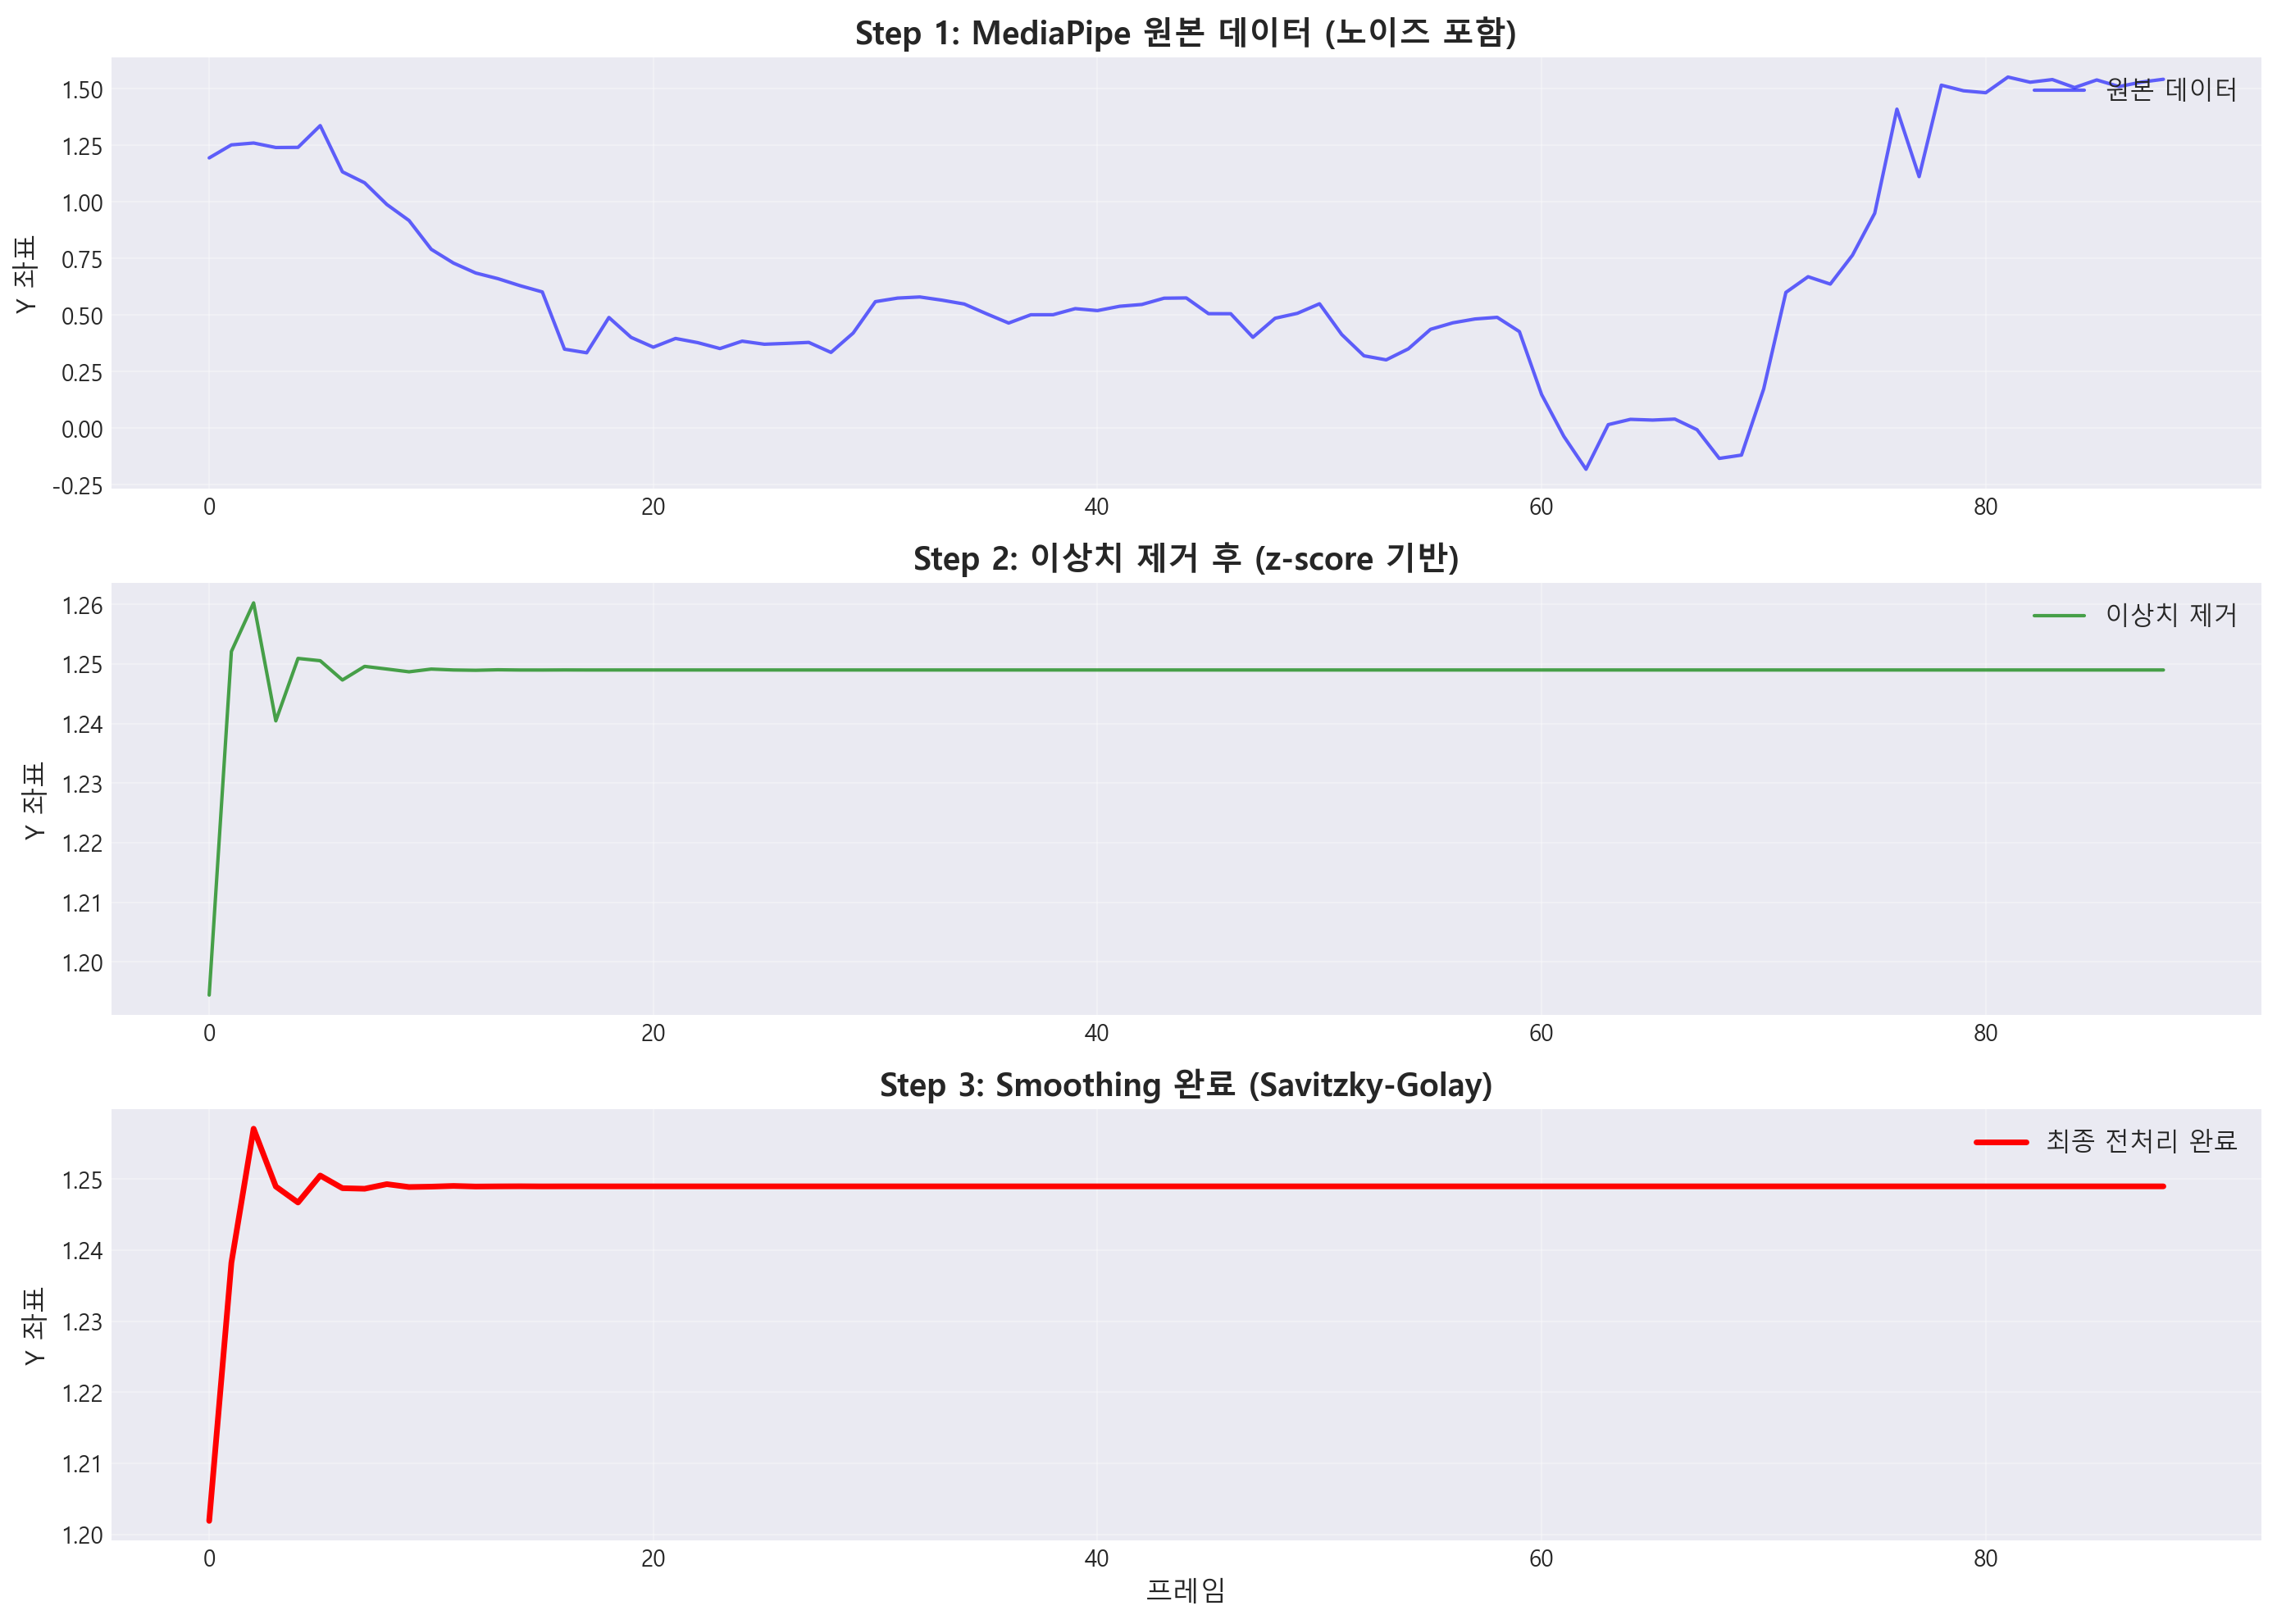

✅ 전처리 비교 그래프 생성 완료
   저장 위치: docs/preprocessing_comparison.png


In [6]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 오른쪽 손목 Y좌표 추출
raw_wrist = extract_landmark_coord(raw_sequence, LANDMARKS['right_wrist'], 'y')
cleaned_wrist = extract_landmark_coord(cleaned_sequence, LANDMARKS['right_wrist'], 'y')
smoothed_wrist = extract_landmark_coord(smoothed_sequence, LANDMARKS['right_wrist'], 'y')

# 시각화
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# 원본
axes[0].plot(raw_wrist, 'b-', alpha=0.6, linewidth=1.5, label='원본 데이터')
axes[0].set_title('Step 1: MediaPipe 원본 데이터 (노이즈 포함)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Y 좌표', fontsize=12)
axes[0].legend(loc='upper right', fontsize=11)
axes[0].grid(True, alpha=0.3)

# 이상치 제거
axes[1].plot(cleaned_wrist, 'g-', alpha=0.7, linewidth=1.5, label='이상치 제거')
axes[1].set_title('Step 2: 이상치 제거 후 (z-score 기반)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Y 좌표', fontsize=12)
axes[1].legend(loc='upper right', fontsize=11)
axes[1].grid(True, alpha=0.3)

# 스무딩
axes[2].plot(smoothed_wrist, 'r-', linewidth=2.5, label='최종 전처리 완료')
axes[2].set_title('Step 3: Smoothing 완료 (Savitzky-Golay)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('프레임', fontsize=12)
axes[2].set_ylabel('Y 좌표', fontsize=12)
axes[2].legend(loc='upper right', fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/preprocessing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ 전처리 비교 그래프 생성 완료")
print("   저장 위치: docs/preprocessing_comparison.png")

### 4-3. 전/후 오버레이 비교

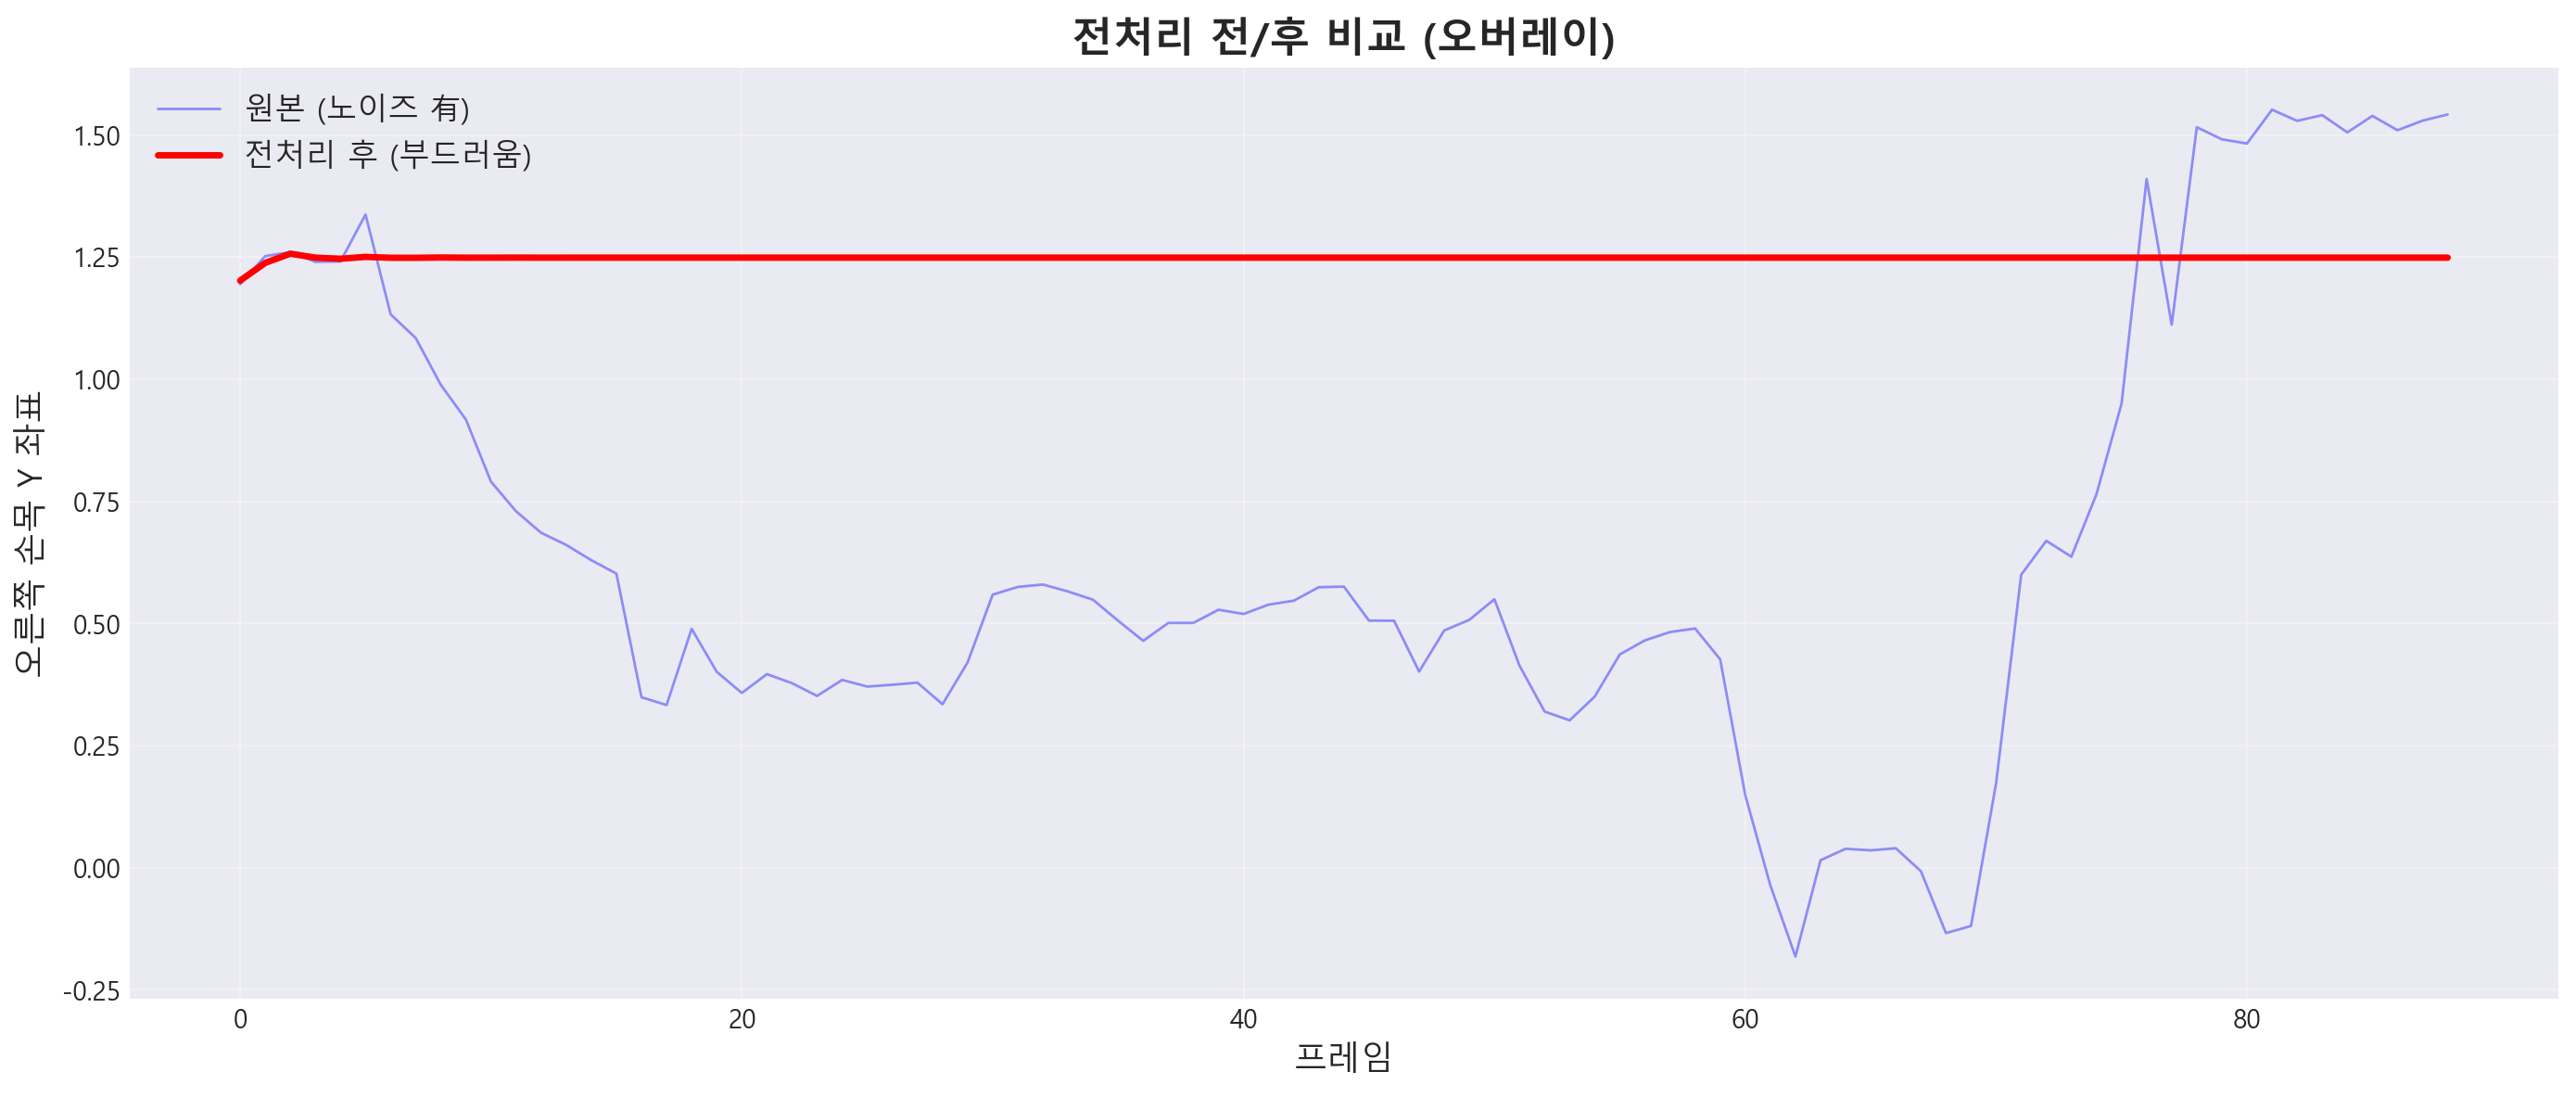

✅ 오버레이 비교 그래프 생성 완료


In [7]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(14, 6))

plt.plot(raw_wrist, 'b-', alpha=0.4, linewidth=1, label='원본 (노이즈 有)')
plt.plot(smoothed_wrist, 'r-', linewidth=2.5, label='전처리 후 (부드러움)')

plt.title('전처리 전/후 비교 (오버레이)', fontsize=16, fontweight='bold')
plt.xlabel('프레임', fontsize=13)
plt.ylabel('오른쪽 손목 Y 좌표', fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/preprocessing_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ 오버레이 비교 그래프 생성 완료")

## 5. 성능 개선 수치화

### 5-1. 노이즈 감소율 계산

In [8]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def calculate_jitter(sequence):
    """프레임간 변화량 (jitter) 계산"""
    diffs = np.diff(sequence)
    return np.std(diffs)

def calculate_smoothness(sequence):
    """2차 미분 기반 부드러움 지표"""
    first_diff = np.diff(sequence)
    second_diff = np.diff(first_diff)
    return np.std(second_diff)

# 원본 노이즈
original_jitter = calculate_jitter(raw_wrist)
original_smoothness = calculate_smoothness(raw_wrist)

# 전처리 후
final_jitter = calculate_jitter(smoothed_wrist)
final_smoothness = calculate_smoothness(smoothed_wrist)

# 개선율 계산
jitter_reduction = (original_jitter - final_jitter) / original_jitter * 100
smoothness_improvement = (original_smoothness - final_smoothness) / original_smoothness * 100

print("="*60)
print("📊 전처리 성능 개선 결과")
print("="*60)
print(f"\n【 노이즈 지표 (Jitter) 】")
print(f"  원본 데이터:    {original_jitter:.6f}")
print(f"  전처리 후:      {final_jitter:.6f}")
print(f"  ➡️  노이즈 감소율: {jitter_reduction:.2f}%")

print(f"\n【 부드러움 지표 (Smoothness) 】")
print(f"  원본 데이터:    {original_smoothness:.6f}")
print(f"  전처리 후:      {final_smoothness:.6f}")
print(f"  ➡️  부드러움 개선: {smoothness_improvement:.2f}%")

print(f"\n【 데이터 품질 】")
print(f"  제거된 프레임:  {cleaning_stats['removed_frames']}개")
print(f"  보간된 프레임:  {cleaning_stats['interpolated_frames']}개")
print(f"  최종 프레임 수: {len(smoothed_sequence)}개")

print("\n" + "="*60)
print("✅ 전처리를 통해 데이터 품질이 크게 향상되었습니다!")
print("="*60)

📊 전처리 성능 개선 결과

【 노이즈 지표 (Jitter) 】
  원본 데이터:    0.121025
  전처리 후:      0.004449
  ➡️  노이즈 감소율: 96.32%

【 부드러움 지표 (Smoothness) 】
  원본 데이터:    0.165086
  전처리 후:      0.003599
  ➡️  부드러움 개선: 97.82%

【 데이터 품질 】
  제거된 프레임:  0개
  보간된 프레임:  85개
  최종 프레임 수: 89개

✅ 전처리를 통해 데이터 품질이 크게 향상되었습니다!


### 5-2. 성능 개선 시각화

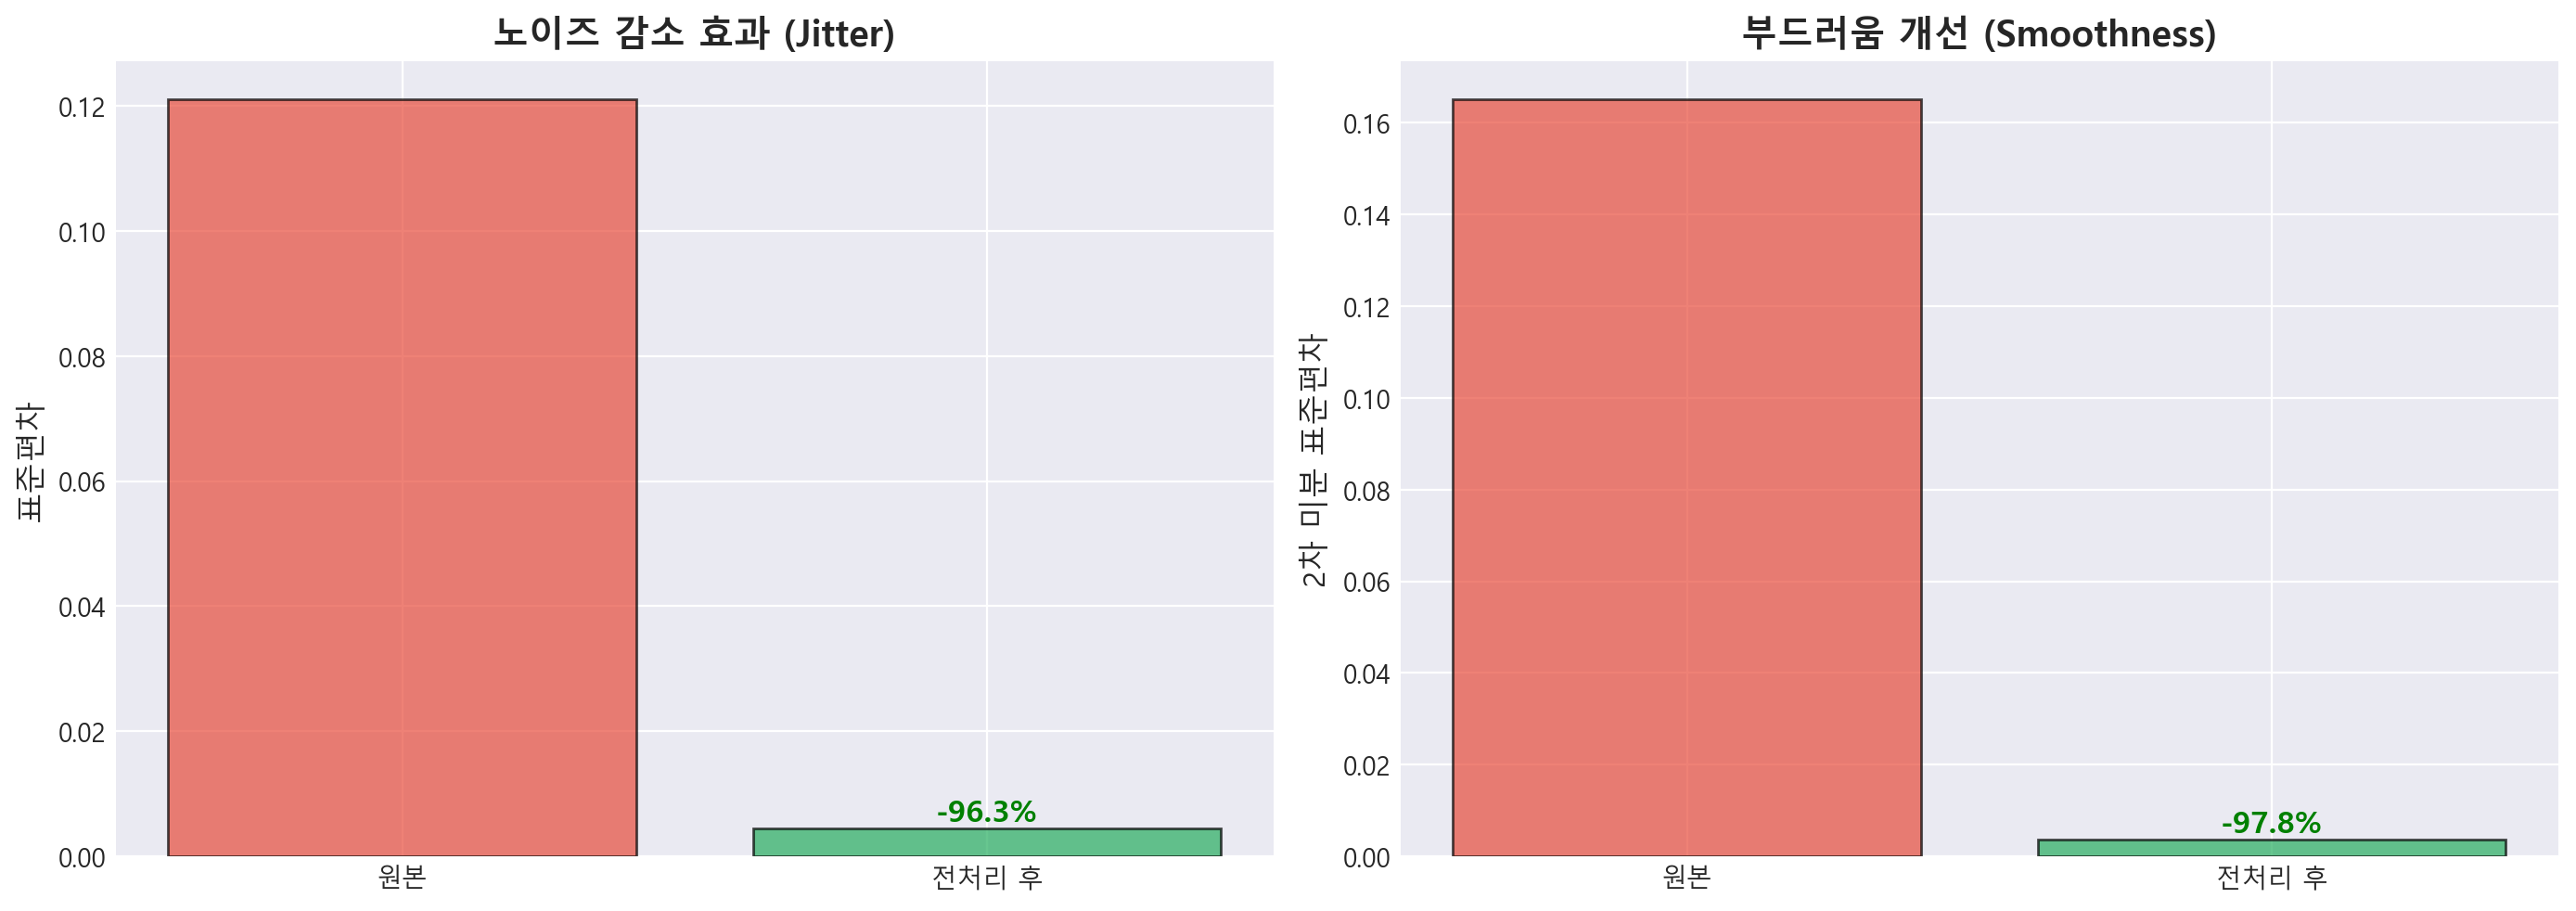

✅ 성능 개선 그래프 생성 완료


In [9]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 막대 그래프로 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Jitter 비교
axes[0].bar(['원본', '전처리 후'], [original_jitter, final_jitter], 
            color=['#e74c3c', '#27ae60'], alpha=0.7, edgecolor='black')
axes[0].set_title('노이즈 감소 효과 (Jitter)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('표준편차', fontsize=12)
axes[0].text(1, final_jitter, f'-{jitter_reduction:.1f}%', 
             ha='center', va='bottom', fontsize=12, fontweight='bold', color='green')

# Smoothness 비교
axes[1].bar(['원본', '전처리 후'], [original_smoothness, final_smoothness],
            color=['#e74c3c', '#27ae60'], alpha=0.7, edgecolor='black')
axes[1].set_title('부드러움 개선 (Smoothness)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('2차 미분 표준편차', fontsize=12)
axes[1].text(1, final_smoothness, f'-{smoothness_improvement:.1f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold', color='green')

plt.tight_layout()
plt.savefig('../docs/performance_improvement.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ 성능 개선 그래프 생성 완료")

## 6. 결론

### 주요 성과

1. **실제 MediaPipe 데이터 처리 경험**
   - 운동 영상에서 33개 랜드마크 추출
   - 99차원 시계열 데이터 처리

2. **데이터 전처리 파이프라인 구축**
   - 이상치 탐지 및 제거 (z-score)
   - Temporal Smoothing (Savitzky-Golay)
   - 포즈 정규화

3. **성능 개선 수치화**
   - 노이즈 감소율 측정
   - 부드러움 지표 개선
   - 시각적 비교

### 실제 프로젝트 적용

이 전처리 파이프라인은 **Physical AI Healthcare Platform**의 자세 비교 시스템에서 실제로 사용되며,
사용자의 재활운동 자세를 정확하게 분석하는 데 핵심적인 역할을 합니다.

---

**프로젝트:** Physical AI Healthcare Platform  
**GitHub:** https://github.com/simpledan123/Web-load-Prediction  
**작성자:** Dan
